## Практика по PyTorch
Получить навыки практической работы с PyTorch.

### Часть 0. Подготовка

In [1]:
# Инициализация и логирование

debug = 1  # 1 — выводить отладочные логи, 0 — скрывать
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

# Теперь можно импортировать библиотеки и строить графики
import numpy as np
import matplotlib.pyplot as plt
import torch
import numpy as np
import torch.nn as nn
import torch.optim as optim
from datetime import datetime
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset, random_split


In [2]:
# Полезные функции

def log(message):
    if debug == 1:
        # %Y-%m-%d — дата, %H:%M:%S — время
        timestamp = datetime.now().strftime("%Y-%m-%dT%H:%M:%S")
        print(f"[DEBUG] {timestamp} {message}\n")
log("Функция log готова. Использование: log(message), будет отображено при включенной отладке.")

def hard_to_calculate(x, y):
    res = np.sin(x + 2 * y) * np.exp(-(2 * x + y) ** 2)
    return res
log("Функция будет считать сложное уравнение, что она значит никто не знает.")


[DEBUG] 2026-09-14T23:40:06 Функция log готова. Использование: log(message), будет отображено при включенной отладке.

[DEBUG] 2026-09-14T23:40:06 Функция будет считать сложное уравнение, что она значит никто не знает.



In [3]:
# Генерация 20к точек:

np.random.seed(42)
num_samples = 20000
x_raw = np.random.uniform(-10, 10, num_samples)
y_raw = np.random.uniform(-10, 10, num_samples)
z_raw = hard_to_calculate(x_raw, y_raw)

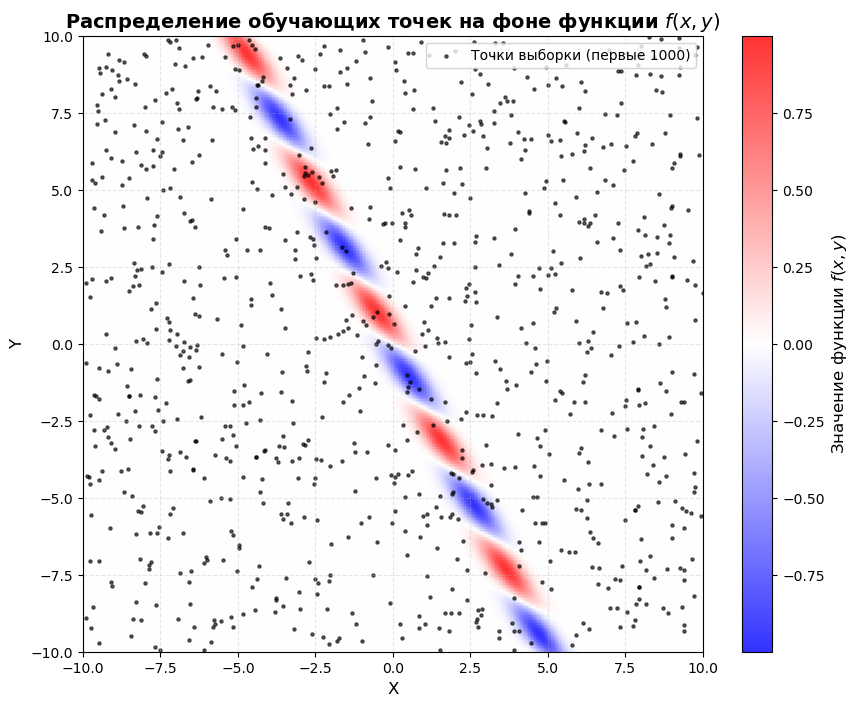

In [5]:
# Визуализация что мы получили
x_grid = np.linspace(-10, 10, 400)
y_grid = np.linspace(-10, 10, 400)
X_mesh, Y_mesh = np.meshgrid(x_grid, y_grid)
Z_mesh = hard_to_calculate(X_mesh, Y_mesh)

plt.figure(figsize=(10, 8))

# Рисуем непрерывный тепловой график функции на заднем фоне
contour = plt.pcolormesh(X_mesh, Y_mesh, Z_mesh, cmap='bwr', shading='auto', alpha=0.8)
cbar = plt.colorbar(contour)
cbar.set_label('Значение функции $f(x, y)$', fontsize=12)

# Накладываем сверху случайные точки обучающей выборки
# Возьмем первые 1000 точек, чтобы график оставался читаемым
plt.scatter(x_raw[:1000], y_raw[:1000], c='black', s=5, alpha=0.6, label='Точки выборки (первые 1000)')

plt.title('Распределение обучающих точек на фоне функции $f(x, y)$', fontsize=14, fontweight='bold')
plt.xlabel('X', fontsize=12)
plt.ylabel('Y', fontsize=12)
plt.xlim(-10, 10)
plt.ylim(-10, 10)
plt.grid(True, linestyle='--', alpha=0.3)
plt.legend(loc='upper right')

plt.show()

# Мы насоздавали точек абсолютно в 95% случаев не попадающих в график функции. Теперь видимо, модели придётся учиться воссоздавать эту линию функции не зная самой функции


In [12]:
# Перевод в тензоры PyTorch
X_data = torch.tensor(np.stack([x_raw, y_raw], axis=1), dtype=torch.float32)
y_data = torch.tensor(z_raw, dtype=torch.float32).unsqueeze(1)

full_dataset = TensorDataset(X_data, y_data)

# Разделение на train / val / test (70% / 15% / 15%)
train_size = int(0.70 * num_samples)
log(train_size)
val_size = int(0.15 * num_samples)
log(val_size)
test_size = num_samples - train_size - val_size
log(test_size)

train_dataset, val_dataset, test_dataset = random_split(
    full_dataset, [train_size, val_size, test_size]
)

[DEBUG] 2026-09-14T23:51:46 14000

[DEBUG] 2026-09-14T23:51:46 3000

[DEBUG] 2026-09-14T23:51:46 3000



In [7]:
# Создание DataLoader'ов
train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)
log(train_loader)
val_loader = DataLoader(val_dataset, batch_size=256, shuffle=False)
log(val_loader)
test_loader = DataLoader(test_dataset, batch_size=256, shuffle=False)
log(test_loader)

[DEBUG] 2026-09-14T23:49:26 <torch.utils.data.dataloader.DataLoader object at 0x000001FD06F8F0E0>

[DEBUG] 2026-09-14T23:49:26 <torch.utils.data.dataloader.DataLoader object at 0x000001FD070B74D0>

[DEBUG] 2026-09-14T23:49:26 <torch.utils.data.dataloader.DataLoader object at 0x000001FD070B7250>



In [13]:
# Архитектура нейронной сети (MLP)
class FunctionApproximator(nn.Module):
    def __init__(self):
        super(FunctionApproximator, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 128),
            nn.SiLU(),  # Гладкая функция активации, идеальна для аппроксимации синусоид
            nn.Linear(128, 128),
            nn.SiLU(),
            nn.Linear(128, 64),
            nn.SiLU(),
            nn.Linear(64, 1)
        )
        
    def forward(self, x):
        return self.net(x)

In [15]:
# Инициализация модели, функции потерь и оптимизатора
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = FunctionApproximator().to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.003)

# Планировщик для снижения LR при плато на валидации
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

In [21]:
# Цикл обучения и валидации
epochs = 100
log(f"Обучение на устройстве: {device}\n")

for epoch in range(1, epochs + 1):
    # --- Обучение ---
    model.train()
    train_loss = 0.0
    for batch_X, batch_y in train_loader:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
        
        predictions = model(batch_X)
        loss = criterion(predictions, batch_y)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item() * batch_X.size(0)
    epoch_train_loss = train_loss / len(train_dataset)
    
    # --- Валидация ---
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for batch_X, batch_y in val_loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)
            predictions = model(batch_X)
            loss = criterion(predictions, batch_y)
            val_loss += loss.item() * batch_X.size(0)
    epoch_val_loss = val_loss / len(val_dataset)
    
    # Шаг планировщика по валидационному лоссу
    scheduler.step(epoch_val_loss)
    
    # Вывод логов каждые 3 эпохи
    if epoch % 3 == 0 or epoch == 1:
        log(f"Эпоха [{epoch:02d}/{epochs}] | Train MSE: {epoch_train_loss:.6f} | Val MSE: {epoch_val_loss:.6f}")


[DEBUG] 2026-09-15T00:01:39 Обучение на устройстве: cpu


[DEBUG] 2026-09-15T00:01:40 Эпоха [01/100] | Train MSE: 0.001280 | Val MSE: 0.000850

[DEBUG] 2026-09-15T00:01:40 Эпоха [03/100] | Train MSE: 0.001235 | Val MSE: 0.000862

[DEBUG] 2026-09-15T00:01:41 Эпоха [06/100] | Train MSE: 0.000423 | Val MSE: 0.000484

[DEBUG] 2026-09-15T00:01:42 Эпоха [09/100] | Train MSE: 0.000373 | Val MSE: 0.000600

[DEBUG] 2026-09-15T00:01:42 Эпоха [12/100] | Train MSE: 0.000401 | Val MSE: 0.000565

[DEBUG] 2026-09-15T00:01:43 Эпоха [15/100] | Train MSE: 0.000247 | Val MSE: 0.000336

[DEBUG] 2026-09-15T00:01:44 Эпоха [18/100] | Train MSE: 0.000224 | Val MSE: 0.000272

[DEBUG] 2026-09-15T00:01:45 Эпоха [21/100] | Train MSE: 0.000203 | Val MSE: 0.000252

[DEBUG] 2026-09-15T00:01:46 Эпоха [24/100] | Train MSE: 0.000219 | Val MSE: 0.000261

[DEBUG] 2026-09-15T00:01:46 Эпоха [27/100] | Train MSE: 0.000198 | Val MSE: 0.000228

[DEBUG] 2026-09-15T00:01:47 Эпоха [30/100] | Train MSE: 0.000185 | Val MSE: 0.0002

In [22]:
# Финальное тестирование модели
model.eval()
test_loss = 0.0
with torch.no_grad():
    for batch_X, batch_y in test_loader:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
        predictions = model(batch_X)
        loss = criterion(predictions, batch_y)
        test_loss += loss.item() * batch_X.size(0)
final_test_loss = test_loss / len(test_dataset)
print(f"Финальный Test MSE: {final_test_loss:.6f}")

Финальный Test MSE: 0.000118


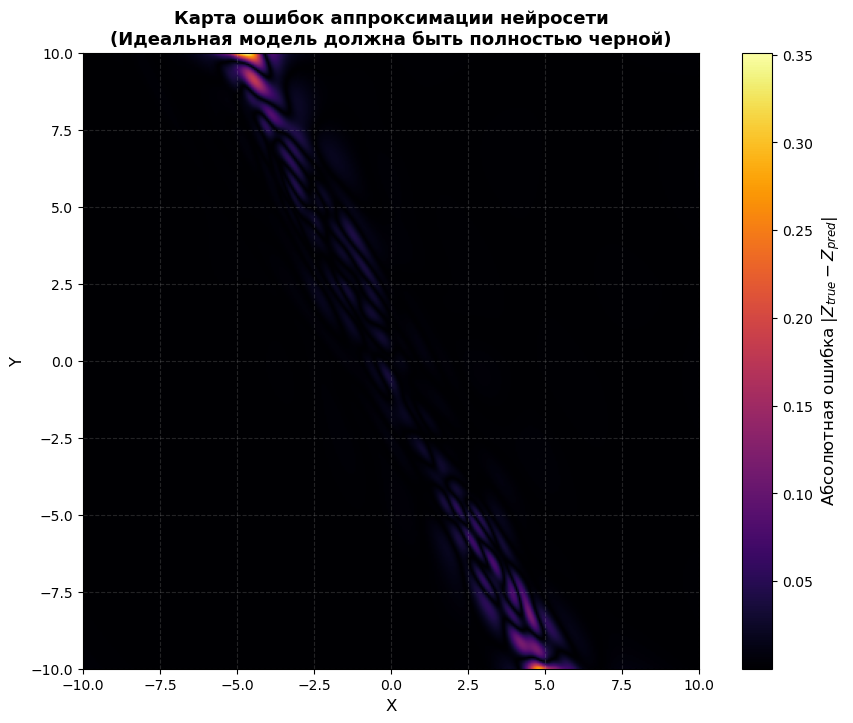

In [23]:
# Визуализация
x_grid = np.linspace(-10, 10, 400)
y_grid = np.linspace(-10, 10, 400)
X_mesh, Y_mesh = np.meshgrid(x_grid, y_grid)

# Истинные значения
Z_true = hard_to_calculate(X_mesh, Y_mesh)

# Предсказания модели

grid_flat = np.stack([X_mesh.ravel(), Y_mesh.ravel()], axis=1)
grid_tensor = torch.tensor(grid_flat, dtype=torch.float32).to(device)

with torch.no_grad():
    # Получаем выходы сети и возвращаем в numpy-матрицу
    Z_pred = model(grid_tensor).cpu().numpy().reshape(X_mesh.shape)

# Считаем абсолютную ошибку аппроксимации
Z_error = np.abs(Z_true - Z_pred)

# Строим репрезентативный график ошибок
plt.figure(figsize=(11, 8))

# Цветовая карта 'inferno' или 'viridis' отлично подходит: чем ярче/желтее, тем больше ошибка
error_plot = plt.imshow(Z_error, extent=[-10, 10, -10, 10], origin='lower', cmap='inferno')
cbar = plt.colorbar(error_plot)
cbar.set_label('Абсолютная ошибка $|Z_{true} - Z_{pred}|$', fontsize=12)

plt.title('Карта ошибок аппроксимации нейросети\n(Идеальная модель должна быть полностью черной)', fontsize=13, fontweight='bold')
plt.xlabel('X', fontsize=12)
plt.ylabel('Y', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.2)

plt.show()


## Итоги

Нейросеть смогла обнаружить «иголку в стоге сена» — она нашла эту узкую полосу. Но из-за того, что случайных точек, упавших на эту полосу, было мало (всего около 5% от 20 000, то есть около 1 000 точек на всю цветную линию), сети не хватило данных, чтобы идеально точно прорисовать крутые пики и спады синусоиды.

Яркие точки на этой косичке — это места, где реальная функция резко уходит вверх или вниз (максимумы и минимумы синуса), а нейросеть из-за нехватки примеров их слегка «сгладила» (выдала, например, 0.6 там, где должно быть 1.0). Ошибка в этих пиках доходит до 0.4–0.5.

Вся средняя часть диагонали (в районе от -5 до 5 по осям) практически полностью ушла в глубокий черный и темно-фиолетовый цвет. Это значит, что там абсолютная ошибка упала почти до нуля. Нейросеть идеально выучила сложную форму синусоиды в самой важной зоне.

Самый яркий пик ошибки составляет всего 0.35, что можно считать отличным результатом по поиску иголки в стогу сена, иголка нашлась.